In [27]:
import pytest
import torch
from torch_geometric.data import Data
from data.datasets import GraphDataset
from data.loaders import (
    load_dataset,
    load_and_split,
    load_and_split_with_khop,
    load_and_split_with_feature_prop
)


In [28]:
# Regime 1: Basic dataset loading
data, dataset = load_dataset("Cora")
print("Basic Dataset Info:")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.edge_index.size(1)}")
print(f"Feature dimensions: {data.x.size()}")
print(f"Number of classes: {len(torch.unique(data.y))}")


Basic Dataset Info:
Number of nodes: 2708
Number of edges: 10556
Feature dimensions: torch.Size([2708, 1433])
Number of classes: 7


In [29]:
# Regime 2: Split into subgraphs
num_clients = 5
beta = 0.5
data, dataset, clients_data, test_data = load_and_split("Cora", num_clients=num_clients, beta=beta)
print("\nRegime 2 - Client Subgraphs:")
for i, client_data in enumerate(clients_data[:2]):  # Show first 2 clients
    print(f"\nClient {i}:")
    print(f"Nodes: {client_data.num_nodes}")
    print(f"Edges: {client_data.edge_index.size(1)}")



Regime 2 - Client Subgraphs:

Client 0:
Nodes: 834
Edges: 1436

Client 1:
Nodes: 263
Edges: 308


In [30]:
# Regime 3: K-hop neighbors with zero features
hop = 1
data, dataset, clients_khop, test_data = load_and_split_with_khop(
    "Cora", 
    num_clients=num_clients, 
    beta=beta, 
    hop=hop
)
print("\nRegime 3 - K-hop Subgraphs:")
for i, client_data in enumerate(clients_khop[:2]):
    print(f"\nClient {i}:")
    print(f"Nodes: {client_data.num_nodes}")
    print(f"Edges: {client_data.edge_index.size(1)}")
    print(f"Zero feature vectors: {torch.sum(torch.all(client_data.x == 0, dim=1))}")



Regime 3 - K-hop Subgraphs:

Client 0:
Nodes: 2334
Edges: 9386
Zero feature vectors: 595

Client 1:
Nodes: 1385
Edges: 5532
Zero feature vectors: 756


In [31]:
# Regime 4: K-hop with feature propagation
data, dataset, clients_prop, test_data = load_and_split_with_feature_prop(
    "Cora", 
    num_clients=num_clients, 
    beta=beta, 
    hop=hop
)
print("\nRegime 4 - Feature Propagation:")
for i, client_data in enumerate(clients_prop[:2]):
    print(f"\nClient {i}:")
    print(f"Nodes: {client_data.num_nodes}")
    print(f"Edges: {client_data.edge_index.size(1)}")
    print(f"Zero feature vectors: {torch.sum(torch.all(client_data.x == 0, dim=1))}")



Regime 4 - Feature Propagation:

Client 0:
Nodes: 1739
Edges: 6746
Zero feature vectors: 0

Client 1:
Nodes: 629
Edges: 2136
Zero feature vectors: 0


In [10]:
# Compare node features across regimes
client_idx = 0  # Pick first client
print("\nFeature Comparison for Client 0:")
print(f"Original subgraph nodes: {clients_data[client_idx].num_nodes}")
print(f"K-hop subgraph nodes: {clients_khop[client_idx].num_nodes}")
print(f"Propagated features nodes: {clients_prop[client_idx].num_nodes}")


Feature Comparison for Client 0:
Original subgraph nodes: 834
K-hop subgraph nodes: 2334
Propagated features nodes: 1739


In [11]:
# Regime 1: Basic dataset loading
print("=== Regime 1: Basic Dataset ===")
data, dataset = load_dataset("Cora")
print("Total nodes:", data.num_nodes)
print("Training nodes:", data.train_mask.sum().item())
print("Validation nodes:", data.val_mask.sum().item())
print("Test nodes:", data.test_mask.sum().item())
print("\n")

# Regime 2: Split into subgraphs
print("=== Regime 2: Split Subgraphs ===")
num_clients = 5
beta = 0.5
data, dataset, clients_data, test_data = load_and_split("Cora", num_clients=num_clients, beta=beta)
for i, client_data in enumerate(clients_data):
    print(f"Client {i}:")
    print(f"Total nodes: {client_data.num_nodes}")
    print(f"Training nodes: {client_data.train_mask.sum().item()}")
    print(f"Validation nodes: {client_data.val_mask.sum().item()}")
    print(f"Test nodes: {client_data.test_mask.sum().item()}")
print("\n")

# Regime 3: K-hop neighbors
print("=== Regime 3: K-hop Subgraphs ===")
hop = 1
data, dataset, clients_khop, test_data = load_and_split_with_khop(
    "Cora", 
    num_clients=num_clients, 
    beta=beta, 
    hop=hop
)
for i, client_data in enumerate(clients_khop):
    print(f"Client {i}:")
    print(f"Total nodes: {client_data.num_nodes}")
    print(f"Training nodes: {client_data.train_mask.sum().item()}")
    print(f"Validation nodes: {client_data.val_mask.sum().item()}")
    print(f"Test nodes: {client_data.test_mask.sum().item()}")
print("\n")

# Regime 4: K-hop with feature propagation
print("=== Regime 4: Feature Propagation ===")
data, dataset, clients_prop, test_data = load_and_split_with_feature_prop(
    "Cora", 
    num_clients=num_clients, 
    beta=beta, 
    hop=hop
)
for i, client_data in enumerate(clients_prop):
    print(f"Client {i}:")
    print(f"Total nodes: {client_data.num_nodes}")
    print(f"Training nodes: {client_data.train_mask.sum().item()}")
    print(f"Validation nodes: {client_data.val_mask.sum().item()}")
    print(f"Test nodes: {client_data.test_mask.sum().item()}")

# Summary statistics
print("\n=== Summary Statistics ===")
print("Original dataset total nodes:", data.num_nodes)
print("\nAverage nodes per client:")
print(f"Regime 2: {sum(c.num_nodes for c in clients_data) / num_clients:.2f}")
print(f"Regime 3: {sum(c.num_nodes for c in clients_khop) / num_clients:.2f}")
print(f"Regime 4: {sum(c.num_nodes for c in clients_prop) / num_clients:.2f}")

print("\nAverage training nodes per client:")
print(f"Regime 2: {sum(c.train_mask.sum().item() for c in clients_data) / num_clients:.2f}")
print(f"Regime 3: {sum(c.train_mask.sum().item() for c in clients_khop) / num_clients:.2f}")
print(f"Regime 4: {sum(c.train_mask.sum().item() for c in clients_prop) / num_clients:.2f}")

=== Regime 1: Basic Dataset ===
Total nodes: 2708
Training nodes: 140
Validation nodes: 500
Test nodes: 1000


=== Regime 2: Split Subgraphs ===
Client 0:
Total nodes: 834
Training nodes: 35
Validation nodes: 152
Test nodes: 306
Client 1:
Total nodes: 263
Training nodes: 18
Validation nodes: 53
Test nodes: 94
Client 2:
Total nodes: 414
Training nodes: 31
Validation nodes: 65
Test nodes: 151
Client 3:
Total nodes: 580
Training nodes: 32
Validation nodes: 115
Test nodes: 194
Client 4:
Total nodes: 617
Training nodes: 24
Validation nodes: 115
Test nodes: 255


=== Regime 3: K-hop Subgraphs ===
Client 0:
Total nodes: 2334
Training nodes: 74
Validation nodes: 328
Test nodes: 638
Client 1:
Total nodes: 1385
Training nodes: 40
Validation nodes: 117
Test nodes: 228
Client 2:
Total nodes: 2109
Training nodes: 65
Validation nodes: 211
Test nodes: 435
Client 3:
Total nodes: 2206
Training nodes: 80
Validation nodes: 264
Test nodes: 538
Client 4:
Total nodes: 1985
Training nodes: 69
Validation node

/Users/brianbosho/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/brianbosho/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/brianbosho/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/brianbosho/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

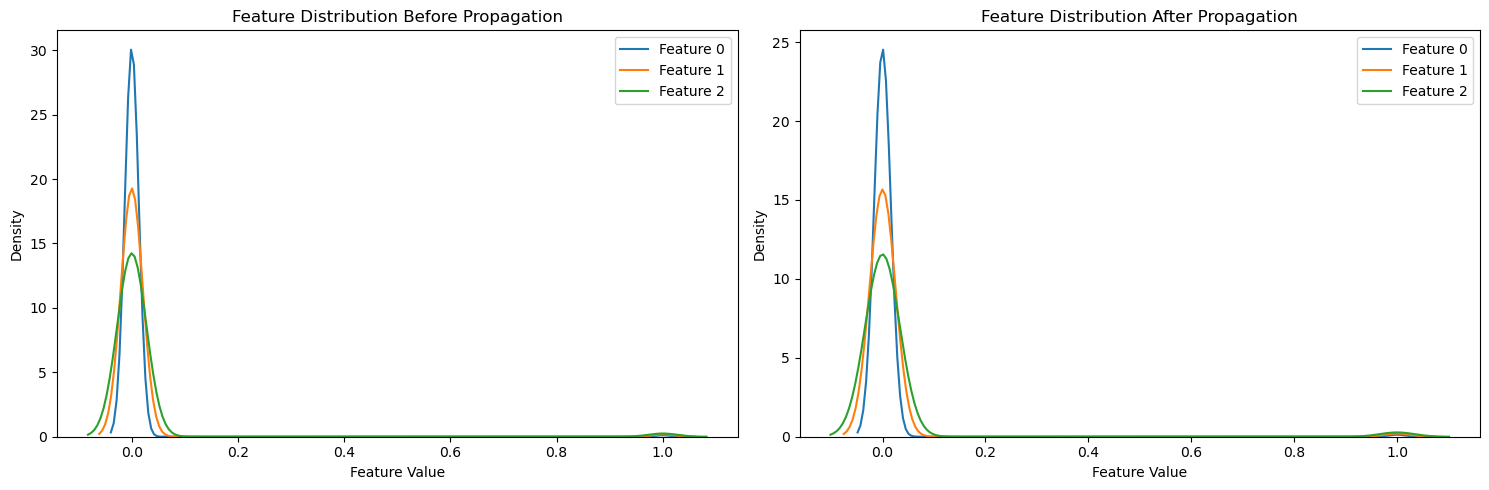

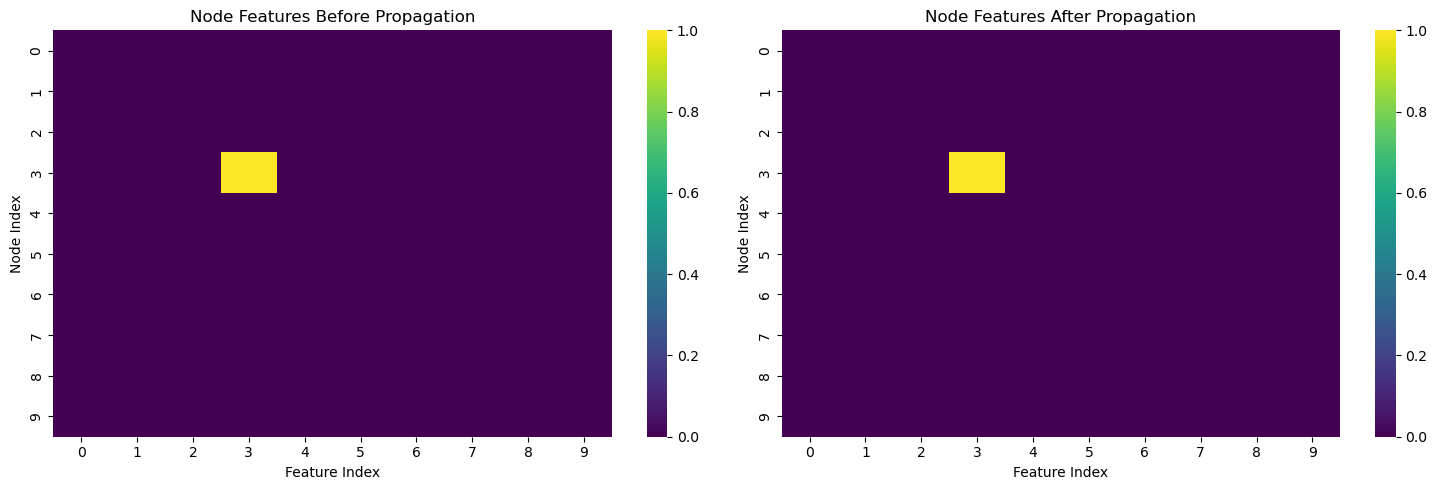


Feature Statistics:

Before Propagation:
Zero vectors: 595
Mean value: 0.0094
Std value: 0.0964

After Propagation:
Zero vectors: 0
Mean value: 0.0126
Std value: 0.1115


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data in different regimes
num_clients = 5
beta = 0.5
hop = 1

# Get data with zero features (Regime 3)
_, _, clients_khop, _ = load_and_split_with_khop(
    "Cora", 
    num_clients=num_clients, 
    beta=beta, 
    hop=hop
)

# Get data with propagated features (Regime 4)
_, _, clients_prop, _ = load_and_split_with_feature_prop(
    "Cora", 
    num_clients=num_clients, 
    beta=beta, 
    hop=hop
)

# Select a client and a few features to visualize
client_idx = 0  # First client
feature_idx = [0, 1, 2]  # First three features

# Get features
zero_features = clients_khop[client_idx].x
prop_features = clients_prop[client_idx].x

# Create visualization
plt.figure(figsize=(15, 5))

# Plot 1: Feature distribution before propagation
plt.subplot(121)
for i, feat in enumerate(feature_idx):
    sns.kdeplot(zero_features[:, feat].cpu().numpy(), label=f'Feature {feat}')
plt.title('Feature Distribution Before Propagation')
plt.xlabel('Feature Value')
plt.ylabel('Density')
plt.legend()

# Plot 2: Feature distribution after propagation
plt.subplot(122)
for i, feat in enumerate(feature_idx):
    sns.kdeplot(prop_features[:, feat].cpu().numpy(), label=f'Feature {feat}')
plt.title('Feature Distribution After Propagation')
plt.xlabel('Feature Value')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()

# Heatmap of a few nodes before and after propagation
n_nodes = 10  # Number of nodes to visualize
n_features = 10  # Number of features to visualize

plt.figure(figsize=(15, 5))

# Plot 1: Features before propagation
plt.subplot(121)
sns.heatmap(zero_features[:n_nodes, :n_features].cpu(), 
            cmap='viridis', 
            xticklabels=range(n_features),
            yticklabels=range(n_nodes))
plt.title('Node Features Before Propagation')
plt.xlabel('Feature Index')
plt.ylabel('Node Index')

# Plot 2: Features after propagation
plt.subplot(122)
sns.heatmap(prop_features[:n_nodes, :n_features].cpu(), 
            cmap='viridis',
            xticklabels=range(n_features),
            yticklabels=range(n_nodes))
plt.title('Node Features After Propagation')
plt.xlabel('Feature Index')
plt.ylabel('Node Index')

plt.tight_layout()
plt.show()

# Print some statistics
print("\nFeature Statistics:")
print("\nBefore Propagation:")
print(f"Zero vectors: {torch.sum(torch.all(zero_features == 0, dim=1)).item()}")
print(f"Mean value: {zero_features.mean().item():.4f}")
print(f"Std value: {zero_features.std().item():.4f}")

print("\nAfter Propagation:")
print(f"Zero vectors: {torch.sum(torch.all(prop_features == 0, dim=1)).item()}")
print(f"Mean value: {prop_features.mean().item():.4f}")
print(f"Std value: {prop_features.std().item():.4f}")

In [22]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from data.loaders import load_dataset
from data.utils import get_propagation_matrix

def propagate_features_with_monitoring(x, edge_index, mask, max_iterations=50, tolerance=1e-6):
    """
    Propagate features and monitor convergence
    
    Args:
        x: Node features
        edge_index: Graph connectivity
        mask: Boolean mask for known features
        max_iterations: Maximum number of iterations
        tolerance: Convergence threshold
    """
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x = x.to(DEVICE)
    mask = mask.bool().to(DEVICE)
    edge_index = edge_index.to(DEVICE)
    
    # Initialize
    if mask is not None:
        out = torch.zeros_like(x)
        out[mask] = x[mask]
    else:
        out = x.clone()
    
    n_nodes = x.size(0)
    adj = get_propagation_matrix(out, edge_index, n_nodes)
    
    # Track changes
    changes = []
    no_of_zero_vectors = []
    
    for iter in range(max_iterations):
        # Store previous state
        prev_out = out.clone()
        no_of_zero_vectors.append(torch.sum(torch.all(out == 0, dim=1)).item())
        
        # Propagate
        out = torch.sparse.mm(adj, out)
        out[mask] = x[mask]  # Reset known features
        
        # Calculate change
        change = torch.norm(out - prev_out).item()
        changes.append(change)
        
        # Check convergence
        # if change < tolerance:
        #     print(f"Converged at iteration {iter}")
        #     break
            
    return out, changes, no_of_zero_vectors


/var/folders/_s/vy3k3hp151b023s2_sgvwv8c0000gn/T/ipykernel_34124/4198940216.py:29: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


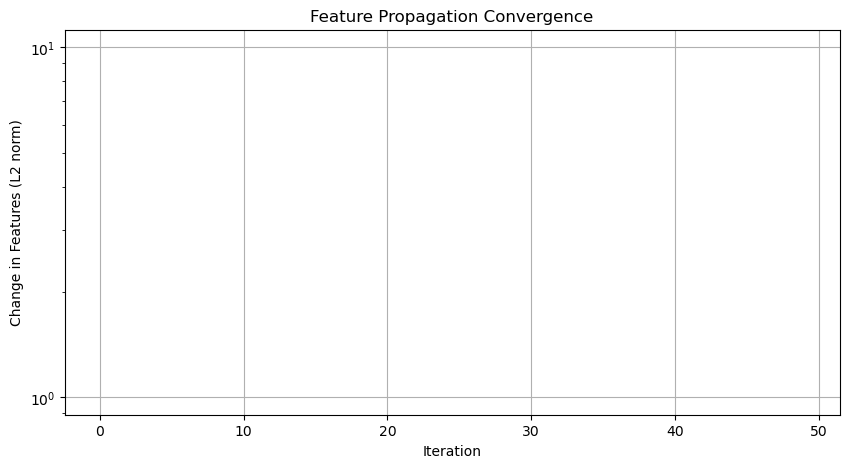


Final change: 0.00000000
Number of iterations: 50


In [24]:

# Load data and test convergence
data, _ = load_dataset("Cora")
num_clients = 5
beta = 0.5
hop = 1

# Get a client's data
_, _, clients_prop, _ = load_and_split_with_feature_prop(
    "Cora", 
    num_clients=num_clients, 
    beta=beta, 
    hop=hop
)

client_data = clients_prop[0]  # First client
zero_vector_mask = (client_data.x == 0).all(dim=1)
non_zero_vector_mask = ~zero_vector_mask

# Propagate features with monitoring
propagated_features, changes, no_of_zero_vectors = propagate_features_with_monitoring(
    client_data.x,
    client_data.edge_index,
    non_zero_vector_mask
)

# Plot convergence
plt.figure(figsize=(10, 5))
plt.plot(changes)
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Change in Features (L2 norm)')
plt.title('Feature Propagation Convergence')
plt.grid(True)
plt.show()

# Print statistics
print(f"\nFinal change: {changes[-1]:.8f}")
print(f"Number of iterations: {len(changes)}")